In [7]:
import pandas as pd

from pathlib import Path

import smtplib, ssl

### Load Scores

In [8]:
exercise_path = Path("course_directory/ads_exercise")
output_path = Path("total_score")

In [9]:
scores = pd.read_csv(exercise_path.joinpath("grades.csv"))
scores.head()

,assignment,duedate,timestamp,student_id,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
0,04_python_basics_III,NaN,NaN,theresanadler,NaN,NaN,NaN,0.0,0.0,0.0,10.0
1,04_python_basics_III,NaN,NaN,moestenfau,NaN,NaN,NaN,0.0,0.0,0.0,10.0
2,04_python_basics_III,NaN,NaN,lucaabel,NaN,NaN,NaN,6.5,0.0,6.5,10.0
3,04_python_basics_III,NaN,NaN,moesten,NaN,NaN,NaN,0.0,0.0,0.0,10.0
4,04_python_basics_III,NaN,NaN,AhmedSofan10,NaN,NaN,NaN,8.0,0.0,8.0,10.0


In [10]:
score_long = scores.set_index(["student_id", "assignment"]).sort_index()
score_long

duedate  timestamp  last_name  first_name  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III      NaN        NaN        NaN         NaN   
             05_dicts_classes          NaN        NaN        NaN         NaN   
             06_numpy_scipy            NaN        NaN        NaN         NaN   
             07_pandas                 NaN        NaN        NaN         NaN   
             08_statistics             NaN        NaN        NaN         NaN   
...                                    ...        ...        ...         ...   
yp69ejot     09-visualization          NaN        NaN        NaN         NaN   
             10-ml                     NaN        NaN        NaN         NaN   
             ads_assignment_1          NaN        NaN        NaN         NaN   
             ads_assignment_2          NaN        NaN        NaN         NaN   
             ads_assignment_3          NaN        NaN        NaN         NaN   

                                   email  raw_score  late_submission_penalty  \
student_id   assignment                                                        
AhmedSofan10 04_python_basics_III    NaN        8.0                      0.0   
             05_dicts_classes        NaN       13.0                      0.0   
             06_numpy_scipy          NaN       10.0                      0.0   
             07_pandas               NaN        9.0                      0.0   
             08_statistics           NaN       11.0                      0.0   
...                                  ...        ...                      ...   
yp69ejot     09-visualization        NaN       11.0                      0.0   
             10-ml                   NaN       17.0                      0.0   
             ads_assignment_1        NaN        1.0                      0.0   
             ads_assignment_2        NaN        8.0                      0.0   
             ads_assignment_3        NaN       10.0                      0.0   

                                   score  max_score  
student_id   assignment                              
AhmedSofan10 04_python_basics_III    8.0       10.0  
             05_dicts_classes       13.0       13.0  
             06_numpy_scipy         10.0       10.0  
             07_pandas               9.0       12.0  
             08_statistics          11.0       11.0  
...                                  ...        ...  
yp69ejot     09-visualization       11.0       11.0  
             10-ml                  17.0       19.0  
             ads_assignment_1        1.0        1.0  
             ads_assignment_2        8.0        8.0  
             ads_assignment_3       10.0       10.0  

[640 rows x 9 columns]

In [11]:
sum_points = score_long["score"].unstack("assignment").sum(axis=1)
sum_points

student_id
AhmedSofan10     92.0
ArefehRh         51.0
Ashikluffy        1.0
Chamutalcast      9.0
Dan-github16      1.0
                ...  
viranya31         1.0
vv88alias       104.0
xindiyu         101.0
youssafB          0.0
yp69ejot        101.0
Length: 64, dtype: float64

In [12]:
score_long.xs("AhmedSofan10", level="student_id")

,duedate,timestamp,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
assignment,,,,,,,,,
04_python_basics_III,NaN,NaN,NaN,NaN,NaN,8.0,0.0,8.0,10.0
05_dicts_classes,NaN,NaN,NaN,NaN,NaN,13.0,0.0,13.0,13.0
06_numpy_scipy,NaN,NaN,NaN,NaN,NaN,10.0,0.0,10.0,10.0
07_pandas,NaN,NaN,NaN,NaN,NaN,9.0,0.0,9.0,12.0
08_statistics,NaN,NaN,NaN,NaN,NaN,11.0,0.0,11.0,11.0
09-visualization,NaN,NaN,NaN,NaN,NaN,11.0,0.0,11.0,11.0
10-ml,NaN,NaN,NaN,NaN,NaN,19.0,0.0,19.0,19.0
ads_assignment_1,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0
ads_assignment_2,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,8.0


In [13]:
max_score = score_long.xs(score_long.index[0][0], level="student_id")["max_score"].sum() # select the first student
max_score

105.0

In [14]:
# set this manually, when the score is not right
max_score = 100.0

In [15]:
percentage = (sum_points / max_score) * 100 
percentage[percentage > 100] = 100
percentage = percentage.sort_values(ascending=False)

<Axes: >

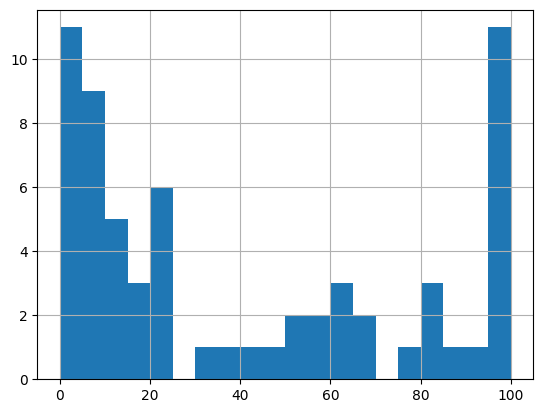

In [16]:
percentage.hist(bins=20)

In [17]:
import time

semester = "SoSe_23"

# export csv
timestr = time.strftime("%Y%m%d-%H%M%S")
percentage.to_csv(output_path.joinpath(semester+"-"+timestr+".csv"))

In [18]:
idm_list = pd.read_csv("course_directory/classroom_roster.csv").loc[:,["identifier", "github_username"]]
idm_list

,identifier,github_username
0,ab99xxxx,theresanadler
1,af31yxin,niculinadragan
2,ak38ryxi,NavalMor
3,al11ytyw,Gschosi
4,al48owam,NaN
...,...,...
86,ys28odyp,NaN
87,ys61uqym,h4xl33t
88,yv49alyr,moestenfau
89,yx26enos,smokemh


In [19]:
idm_list.set_index("github_username", inplace=True)
idm_list.index.name = "student_id"

In [20]:
idm_list

,identifier
student_id,
theresanadler,ab99xxxx
niculinadragan,af31yxin
NavalMor,ak38ryxi
Gschosi,al11ytyw
NaN,al48owam
...,...
NaN,ys28odyp
h4xl33t,ys61uqym
moestenfau,yv49alyr


In [21]:
# join percentage and idm_list

total = pd.DataFrame(percentage, columns=["score_percent"]).join(idm_list, how="inner")
total

,score_percent,identifier
student_id,,
AhmedSofan10,92.0,za07ryma
ArefehRh,51.0,ju47kato
Ashikluffy,1.0,ix31ipix
Chamutalcast,9.0,sy23hoza
Dan-github16,1.0,na30dopa
...,...,...
viranya31,1.0,yq13isef
vv88alias,100.0,we70xebi
xindiyu,100.0,vo28hudo


In [22]:
# drop all rows with identifier length > 8 

total.drop(total[total['identifier'].str.len() > 8].index, inplace = True)

In [23]:
total

,score_percent,identifier
student_id,,
AhmedSofan10,92.0,za07ryma
ArefehRh,51.0,ju47kato
Ashikluffy,1.0,ix31ipix
Chamutalcast,9.0,sy23hoza
Dan-github16,1.0,na30dopa
EmilyKratsch,59.0,go63gaxo
FA-538,42.0,lo27cyru
Gschosi,100.0,al11ytyw
Jonas185,24.0,aq28onip


In [16]:
total = total.reset_index().set_index("identifier").drop("student_id", axis=1).sort_index()
total

,score_percent
identifier,
ab99xxxx,10.0
af31yxin,14.5
ak38ryxi,9.0
al11ytyw,100.0
am42ybuv,9.0
...,...
yq13isef,1.0
ys61uqym,9.0
yv49alyr,11.0


In [26]:
total.to_csv(output_path.joinpath("2023_total.csv"))

In [18]:
mails = pd.read_csv('studon_export/mails/mails.csv')
mails = mails[["Login", "E-Mail", "First Name", "Last Name"]]
mails

,Login,E-Mail,First Name,Last Name
0,lo27cyru,faysal.ahmed@fau.de,Faysal,Ahmed
1,qe72syka,shahd.alhaj@fau.de,Shahd,Alhaj
2,du62koko,sushmetha.arumugam@fau.de,Sushmetha,Arumugam
3,ed10ipan,atefeh.azad@fau.de,Atefeh,Azad
4,il71ywod,ekaterina.bobrova@fau.de,Ekaterina,Bobrova
...,...,...,...,...
76,if80ajil,charlotte.wiebecke@fau.de,Charlotte,Wiebecke
77,ja62sysi,fan.f.xia@fau.de,Fan,Xia
78,xe61xija,rania.younis@fau.de,Rania,Younis
79,vo28hudo,xindi.yu@fau.de,Xindi,Yu


In [19]:
# rename columns
mails = mails.rename({"Login":"identifier", "E-Mail":"email", "First Name":"first_name", "Last Name":"last_name"}, axis=1).set_index("identifier")
mails

,email,first_name,last_name
identifier,,,
lo27cyru,faysal.ahmed@fau.de,Faysal,Ahmed
qe72syka,shahd.alhaj@fau.de,Shahd,Alhaj
du62koko,sushmetha.arumugam@fau.de,Sushmetha,Arumugam
ed10ipan,atefeh.azad@fau.de,Atefeh,Azad
il71ywod,ekaterina.bobrova@fau.de,Ekaterina,Bobrova
...,...,...,...
if80ajil,charlotte.wiebecke@fau.de,Charlotte,Wiebecke
ja62sysi,fan.f.xia@fau.de,Fan,Xia
xe61xija,rania.younis@fau.de,Rania,Younis


In [20]:
email_result = total.join(mails, how="inner")
email_result

,score_percent,email,first_name,last_name
identifier,,,,
af31yxin,14.5,niculina.dragan@studium.fau.de,Niculina,Dragan
ak38ryxi,9.0,naval.s.mor@fau.de,Naval Shukhabhai,Mor
al11ytyw,100.0,markus.gschossmann@fau.de,Markus,Gschoßmann
am42ybuv,9.0,doro.dressel@fau.de,Doro,Dreßel
an89ibyq,24.0,miri.kurz@fau.de,Miriam,Kurz
aq28onip,24.0,jonas.raps@fau.de,Jonas,Raps
eb37yzyp,9.0,syeda.kainat.bukhari@fau.de,Syeda Kainat,Bukhari
ew73ugaf,82.0,luzie.richter@fau.de,Luzie,Richter
ez72oxib,75.0,abdallah.eid@fau.de,Abdallah,Eid


In [29]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

import time

In [33]:
# write mail
smtp_server = "smtp.gmail.com"
port = 587  # For starttls
sender_email = "dipsylab@gmail.com"
password = "eestjmljnibjgesu"

# Create a secure SSL context
context = ssl.create_default_context()

# Try to log in to server and send email
try:
    server = smtplib.SMTP(smtp_server,port)
    server.ehlo() # Can be omitted
    server.starttls(context=context) # Secure the connection
    server.ehlo() # Can be omitted
    server.login(sender_email, password)
    
    # send mail here
    for identifier, student in email_result[:5].iterrows():
        message = MIMEMultipart()

        message["From"] = sender_email
        message["To"] = student.email
        message["Subject"] = "ADS Exercise Result"

        # Add body to email
        
        message.attach(MIMEText(f"Hi {student.first_name}, \n\n your total score is {round(student.score_percent, 1)} %.  \n\n Best regards, \n ADS Team", "plain"))
        
        message.attach(MIMEText(f"\n\n This message was automatically generated. Please do not reply to this email.", "plain")

        server.sendmail(sender_email, "luca.abel@fau.de", message.as_string())
        #wait for 1 second

        time.sleep(1)    
    
except Exception as e:
    # Print any error messages to stdout
    print(e)
finally:
    server.quit() 